# MCTSPolicy: parallel rollouts via vmap (CPU vs MPS)

`MCTSPolicy` runs `mctx.gumbel_muzero_policy` inside a single JIT —
`lax.fori_loop` over `num_simulations`, fully on-device. A single
search is sequential. The lever for MPS speedup is `jax.vmap` over
B independent searches: one batched kernel of shape `(B, …)` per
simulation step replaces B sequential single-state kernels.

This notebook benchmarks both:

1. `## 3` — sequential B=1 sweep over `num_simulations` (CPU wins by
   orders of magnitude on this scenario size).
2. `## 4` — batched sweep over B at fixed `num_simulations`. MPS
   per-batch wall time stays roughly flat, so per-search time drops
   as 1/B.

For MPS install / setup / float32 / memory tuning, see
`running_on_mps.ipynb`.

In [1]:
# Configure JAX before any jax import. `jax-mps` installs its plugin
# under the `jax_plugins.mps` namespace; we probe via importlib.metadata.
import importlib.metadata
import os

try:
    importlib.metadata.distribution('jax-mps')
    HAS_JAX_MPS = True
except importlib.metadata.PackageNotFoundError:
    HAS_JAX_MPS = False

if HAS_JAX_MPS:
    os.environ['JAX_PLATFORMS'] = 'cpu,mps'
    os.environ['JAX_DEFAULT_DEVICE'] = 'cpu'
else:
    os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import sys
from pathlib import Path
_here = Path.cwd()
if (_here / 'src' / 'orbital_game').is_dir():
    _repo_root = _here
elif (_here.parent / 'src' / 'orbital_game').is_dir():
    _repo_root = _here.parent
else:
    raise RuntimeError(f'Could not locate orbital-game repo root from cwd={_here}')
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2

import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import orbital_game
orbital_game.set_precision(jnp.float32)

from orbital_game import OrbitalGameEnv, Side
from orbital_game.adapters.pomdp import POMDPAdapter
from orbital_game.policies.mcts import MCTSPolicy
from orbital_game.policies.uniform_random import UniformRandomDiscretePolicy
from examples.lbg_ring_intercept import build_scenario, RingInterceptParams

print('JAX', jax.__version__, '| default backend:', jax.default_backend())
print('CPU devices:', jax.devices('cpu'))
try:
    mps = jax.devices('mps')
    HAS_MPS = True
    print('MPS devices:', mps)
except RuntimeError:
    HAS_MPS = False
    print('MPS not available — install with: pip install orbital-game[mps]')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Platform 'mps' is experimental and not all JAX functionality may be correctly supported!


JAX 0.10.0 | default backend: cpu
CPU devices: [CpuDevice(id=0)]
MPS devices: [MpsDevice(id=0)]


## 1. Scenario

17-D flat state, 9-action grid. Per-iteration math is small enough
that per-kernel dispatch overhead dominates at low B, which is what
we want for the launch-overhead crossover to be visible.

In [2]:
params = RingInterceptParams(
    n_bandits=2,
    ring_radius_m=2000.0,
    guard_ring_radius_m=200.0,
    breach_radius_m=5.0,
    catch_radius_m=50.0,
    dt=10.0,
    max_horizon_s=600.0,
    seed=0,
)
cfg = build_scenario(params)
env = OrbitalGameEnv(cfg)
adapter = POMDPAdapter(env)

WET = 12.0 + 3.0  # cold-gas wet mass
DV_MAX = 3.6 * cfg.dt / WET

angles = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
grid_2d = DV_MAX * np.stack([np.cos(angles), np.sin(angles)], axis=-1)
action_grid = jnp.asarray(np.concatenate([grid_2d, np.zeros((1, 2))], axis=0), dtype=jnp.float32)

print(f'states_dim = {adapter.states_dim} | A = {action_grid.shape[0]}')


states_dim = 17 | A = 9


## 2. Helpers

- `build_mcts(env, adapter, num_simulations)` — fresh policy.
- `time_call(policy, s, t)` — single-state benchmark (B=1).
- `reset_batch(env, adapter, B)` — B independent flat states via
  `jax.vmap(env.reset → adapter.pack)`.
- `time_batched(policy, s_batch, t)` — vmapped benchmark over B states.

In [3]:
def build_mcts(env_, adapter_, num_simulations: int) -> MCTSPolicy:
    opp = UniformRandomDiscretePolicy(
        action_grid=action_grid,
        n_vehicles=cfg.n_bandits,
        command_cls=env_.bandit_command_cls,
    )
    return MCTSPolicy(
        env_model=adapter_,
        side=Side.GUARD,
        action_grid=action_grid,
        opponent_model=opp,
        opponent_action_grid=action_grid,
        num_simulations=num_simulations,
        n_vehicles=cfg.n_guards,
        command_cls=env_.guard_command_cls,
    )


def time_call(policy, s_flat, t, n_warmup: int = 1, n_calls: int = 3):
    """Warm-up + n_calls timed single-state calls (B=1)."""
    keys = jax.random.split(jax.random.PRNGKey(0), n_warmup + n_calls)
    @jax.jit
    def _call(s, k, tt):
        return policy(None, s, k, tt)
    for i in range(n_warmup):
        cmd, _ = _call(s_flat, keys[i], t)
        cmd.dv.block_until_ready()
    t0 = time.perf_counter()
    for i in range(n_warmup, n_warmup + n_calls):
        cmd, _ = _call(s_flat, keys[i], t)
        cmd.dv.block_until_ready()
    return (time.perf_counter() - t0) / n_calls


def reset_batch(env_, adapter_, B: int, seed: int = 0):
    """Build B independent flat-state vectors via vmap(env.reset → adapter.pack)."""
    keys = jax.random.split(jax.random.PRNGKey(seed), B)
    @jax.vmap
    def _one(k):
        s, _ = env_.reset(k)
        return adapter_.pack(s)
    return _one(keys)


def time_batched(policy, s_flat_batch, t, n_warmup: int = 1, n_calls: int = 3):
    """Warm-up + n_calls timed batched calls — `jax.vmap` over B states."""
    B = s_flat_batch.shape[0]
    keys = jax.random.split(jax.random.PRNGKey(1), n_warmup + n_calls)
    @jax.jit
    def _batched(s_batch, k_batch, tt):
        return jax.vmap(lambda s, k: policy(None, s, k, tt))(s_batch, k_batch)
    for i in range(n_warmup):
        sub = jax.random.split(keys[i], B)
        cmd, _ = _batched(s_flat_batch, sub, t)
        cmd.dv.block_until_ready()
    t0 = time.perf_counter()
    for i in range(n_warmup, n_warmup + n_calls):
        sub = jax.random.split(keys[i], B)
        cmd, _ = _batched(s_flat_batch, sub, t)
        cmd.dv.block_until_ready()
    return (time.perf_counter() - t0) / n_calls

## 3. Sequential baseline (B=1)

Sweep `num_simulations` at B=1. A single MCTS search is sequential
and per-iteration math is small, so CPU's near-zero kernel-launch
overhead beats MPS by 4+ orders of magnitude. We sweep only small
`num_simulations` because MPS at B=1 is glacial here.

In [4]:
state, _ = env.reset(jax.random.PRNGKey(0))
sweep_sims = [16, 32]

print(f'{"num_sims":>8} | {"CPU (ms)":>10} | {"MPS (ms)":>10} | {"speedup":>8}')
print('-' * 48)
for num_sims in sweep_sims:
    cpu_pol = build_mcts(env, adapter, num_sims)
    s_flat_cpu = adapter.pack(state)
    cpu_ms = 1000 * time_call(cpu_pol, s_flat_cpu, state.t)

    if HAS_MPS:
        with jax.default_device(jax.devices('mps')[0]):
            env_mps = OrbitalGameEnv(cfg)
            adapter_mps = POMDPAdapter(env_mps)
            state_mps, _ = env_mps.reset(jax.random.PRNGKey(0))
            mps_pol = build_mcts(env_mps, adapter_mps, num_sims)
            s_flat_mps = adapter_mps.pack(state_mps)
            mps_ms = 1000 * time_call(mps_pol, s_flat_mps, state_mps.t)
        speedup = cpu_ms / mps_ms
        print(f'{num_sims:>8} | {cpu_ms:>10.1f} | {mps_ms:>10.1f} | {speedup:>7.4f}x')
    else:
        print(f'{num_sims:>8} | {cpu_ms:>10.1f} | {"-":>10} | {"-":>8}')

num_sims |   CPU (ms) |   MPS (ms) |  speedup
------------------------------------------------
      16 |        0.4 |     5383.9 |  0.0001x
      32 |        8.8 |    24590.2 |  0.0004x


## 4. Batched search — vmap over independent states

Each lane runs an independent MCTS search over its own initial state.
`jax.vmap` lifts the per-state policy call into a single batched JIT'd
function: per simulation step the kernel processes all B states in
one dispatch.

Hold `num_simulations` fixed, sweep B. Per-batch MPS wall time should
stay ~flat (one batched kernel does B times more work for the same
dispatch cost); per-search time should drop as 1/B.

In [5]:
NUM_SIMS_BATCH = 16
B_sweep = [1, 4, 16, 64, 256, 512, 1024, 2048, 4096]
cpu_per_search = []
mps_per_search = []

print(f'Fixed num_simulations = {NUM_SIMS_BATCH}')
print(f'{"B":>4} | {"CPU/batch (ms)":>15} | {"MPS/batch (ms)":>15} | {"CPU/srch (ms)":>14} | {"MPS/srch (ms)":>14} | {"speedup":>8}')
print('-' * 86)

for B in B_sweep:
    # CPU
    cpu_pol = build_mcts(env, adapter, NUM_SIMS_BATCH)
    s_flat_cpu = reset_batch(env, adapter, B)
    cpu_ms = 1000 * time_batched(cpu_pol, s_flat_cpu, state.t)
    cpu_each = cpu_ms / B
    cpu_per_search.append(cpu_each)

    if HAS_MPS:
        with jax.default_device(jax.devices('mps')[0]):
            env_mps = OrbitalGameEnv(cfg)
            adapter_mps = POMDPAdapter(env_mps)
            state_mps, _ = env_mps.reset(jax.random.PRNGKey(0))
            mps_pol = build_mcts(env_mps, adapter_mps, NUM_SIMS_BATCH)
            s_flat_mps = reset_batch(env_mps, adapter_mps, B)
            mps_ms = 1000 * time_batched(mps_pol, s_flat_mps, state_mps.t)
        mps_each = mps_ms / B
        mps_per_search.append(mps_each)
        speedup = cpu_each / mps_each
        print(f'{B:>4} | {cpu_ms:>15.1f} | {mps_ms:>15.1f} | {cpu_each:>14.3f} | {mps_each:>14.3f} | {speedup:>7.3f}x')
    else:
        mps_per_search.append(float('nan'))
        print(f'{B:>4} | {cpu_ms:>15.1f} | {"-":>15} | {cpu_each:>14.3f} | {"-":>14} | {"-":>8}')

Fixed num_simulations = 16
   B |  CPU/batch (ms) |  MPS/batch (ms) |  CPU/srch (ms) |  MPS/srch (ms) |  speedup
--------------------------------------------------------------------------------------
   1 |             0.6 |          5210.4 |          0.551 |       5210.375 |   0.000x
   4 |             0.9 |          5189.4 |          0.234 |       1297.351 |   0.000x
  16 |             0.8 |          5548.9 |          0.049 |        346.807 |   0.000x
  64 |             1.5 |          5607.9 |          0.023 |         87.624 |   0.000x
 256 |             4.0 |          5569.9 |          0.016 |         21.758 |   0.001x
 512 |             8.0 |          5534.6 |          0.016 |         10.810 |   0.001x
1024 |            18.4 |          5217.3 |          0.018 |          5.095 |   0.004x
2048 |            33.9 |          4978.0 |          0.017 |          2.431 |   0.007x
4096 |            58.6 |          4965.6 |          0.014 |          1.212 |   0.012x


## 5. Throughput plot

Per-search wall time vs. B on log-log axes. CPU stays roughly flat
per search; MPS slopes downward toward CPU as dispatch amortizes.

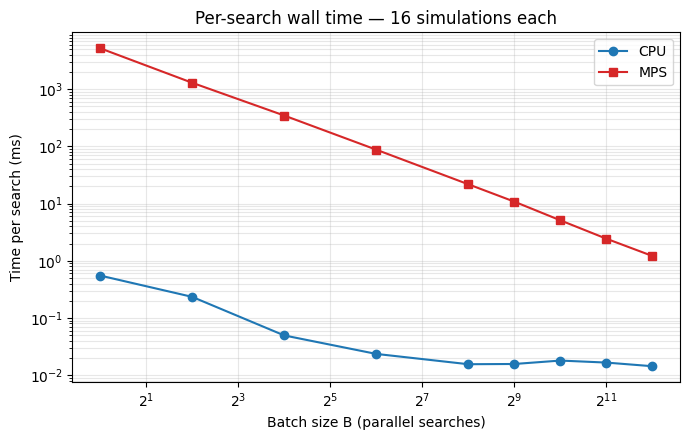


Throughput (searches / second):
   B |        CPU |        MPS
--------------------------------
   1 |     1814.6 |        0.2
   4 |     4280.7 |        0.8
  16 |    20222.9 |        2.9
  64 |    42598.0 |       11.4
 256 |    64481.1 |       46.0
 512 |    63905.9 |       92.5
1024 |    55679.8 |      196.3
2048 |    60368.7 |      411.4
4096 |    69917.1 |      824.9


In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(B_sweep, cpu_per_search, 'o-', color='C0', label='CPU')
if HAS_MPS:
    ax.plot(B_sweep, mps_per_search, 's-', color='C3', label='MPS')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('Batch size B (parallel searches)')
ax.set_ylabel('Time per search (ms)')
ax.set_title(f'Per-search wall time — {NUM_SIMS_BATCH} simulations each')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.show()

print('\nThroughput (searches / second):')
print(f'{"B":>4} | {"CPU":>10} | {"MPS":>10}')
print('-' * 32)
for i, B in enumerate(B_sweep):
    cpu_tput = 1000.0 / cpu_per_search[i]
    mps_tput = (1000.0 / mps_per_search[i]) if HAS_MPS else float('nan')
    mps_str = f'{mps_tput:>10.1f}' if HAS_MPS else f'{"-":>10}'
    print(f'{B:>4} | {cpu_tput:>10.1f} | {mps_str}')